# Lab - Parallel Computing Part 2 - GPU Kernel Timing

## E6692 Spring 2026


### <font color="red"><strong>[Important]</strong></font> Complete **Part 1: Define GPU Kernel Functions for a Deep Learning Model** before starting this part.

In [1]:
# Run this cell to perform imports and initialize necessary modules
import numpy as np
import torch
import torch.nn.functional as F
import time

from utils.context import Context, GPUKernels
from utils.plot_execution_times import plot_execution_times, INPUT_SIZES

# define GPU
device = torch.device('cuda')

# define block size
BLOCK_SIZE = 32

# define timing iterations
iterations = 10

# define kernel path
kernel_path = './kernels.cu'

%load_ext autoreload
%autoreload 2

%matplotlib inline

## Part 2: GPU Kernel Timing

Now that we have implemented CUDA versions of deep learning network layers and verified the results against PyTorch's versions, we will compare the execution times of our CUDA implementation against PyTorch CPU and PyTorch GPU execution times. PyTorch simplifies almost all of the GPU memory allocation and context management. Data is sent to the GPU with the **.to(device)** method, where device is the **torch.device()** object defined in the first cell that corresponds to the Jetson Nano's GPU. The following cell gives an example of how to time operations and execute PyTorch operations on CPU vs GPU with the **relu()** function. 

### ReLU Timing

<font color="red"><strong>TODO:</strong></font> Run the following cells.

In [2]:
context = Context(BLOCK_SIZE)
source_module = context.getSourceModule(kernel_path)
cuda_functions = GPUKernels(context, source_module)

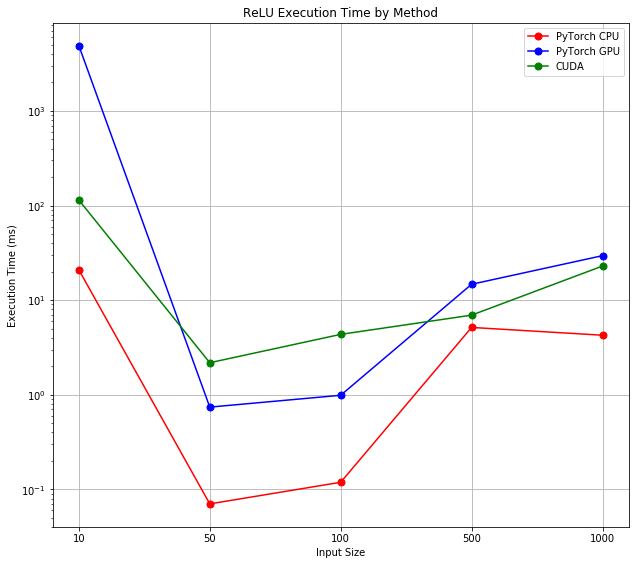

In [3]:
# relu time profiling example

# define timing lists
time_pytorch_cpu = []
time_pytorch_gpu = []
time_cuda = []

for input_size in INPUT_SIZES:
    
    time_pytorch_cpu_total = 0
    time_pytorch_gpu_total = 0
    time_cuda_total = 0
    
    # average execution times for more stable and accurate results
    for _ in range(iterations):
    
        # define input array
        input_array = np.random.randint(-10, high=10, size=(input_size, input_size))

        # define PyTorch input array
        input_array_pytorch_cpu = torch.from_numpy(input_array)

        # profile CPU PyTorch
        pytorch_cpu_start = time.time()
        output_array_pytorch_cpu = F.relu(input_array_pytorch_cpu)
        pytorch_cpu_end = time.time()

        # add pytorch CPU time to list
        time_pytorch_cpu_total += (pytorch_cpu_end - pytorch_cpu_start) * 1000

        # profile GPU PyTorch (including memory transfer)
        pytorch_gpu_start = time.time()
        input_array_pytorch_gpu = input_array_pytorch_cpu.to(device)
        output_array_pytorch_gpu = F.relu(input_array_pytorch_gpu)
        output_array_pytorch_gpu = output_array_pytorch_gpu.cpu()
        torch.cuda.synchronize()
        pytorch_gpu_end = time.time()

        # add pytorch GPU time to list
        time_pytorch_gpu_total += (pytorch_gpu_end - pytorch_gpu_start) * 1000

        # profile CUDA (including memory transfer)
        cuda_start = time.time()
        cuda_output = cuda_functions.relu(input_array)
        torch.cuda.synchronize()
        cuda_end = time.time()

        # add CUDA time to list
        time_cuda_total += (cuda_end - cuda_start) * 1000
        
    time_pytorch_cpu.append(time_pytorch_cpu_total / iterations)
    time_pytorch_gpu.append(time_pytorch_gpu_total / iterations)
    time_cuda.append(time_cuda_total / iterations)

# plot times
title = "ReLU Execution Time by Method"
plot_execution_times(time_pytorch_cpu, time_pytorch_gpu, time_cuda, title)


### Discuss the results of the relu() time profile:

#### 1. Are the GPU implementations faster than PyTorch CPU implementation? Why or why not?

<font color="red"><strong>TODO:</strong></font> No, GPUs are always slower. As can be seen from the time graph, for smaller inputs, the running speed implemented by the GPU is much lower than that of PyTorch on the CPU, and they only become competitive at certain larger input scales. The main reason is that ReLU is a very simple element-level operation. Due to this, the actual computational cost is very low, while the overhead of starting the GPU kernel and transferring data between the CPU and GPU dominates the total execution time. 
This additional expense is much greater than the cost of the computation itself, so it is faster to execute on the CPU.

#### 2. How does our CUDA implementation or ReLU compare to PyTorch's GPU implementation?

<font color="red"><strong>TODO:</strong></font> Our CUDA implementation is usually slower than the GPU implementation of PyTorch, but when the input data is 50 or 100, CUDA is the fastest. This phenomenon can be explained by the balance between parallel benefits and costs， 
When the input size is small, the data transmission and kernel startup overhead of the GPU dominate, so CUDA is slower.
When the input size is very large, the optimization advantage of PyTorch begins to show, so its GPU implementation is faster.
While at medium sizes (such as 50 and 100), our CUDA implementation has already been able to take advantage of parallel computing, and the overhead is not too large, thus achieving the best performance.

#### 3. Based on your observations for question 1, is it worth computing ReLU activation by itself on GPU? If not, why is this function still needed for GPU deep learning implementations?

<font color="red"><strong>TODO:</strong></font> YIf we simply send the data to the GPU just to perform one ReLU operation, it is usually not worth it, especially for small or medium-sized inputs. This is because the transmission and startup costs are often higher than the actual computations. 
However, ReLU remains indispensable in GPU-based deep learning because it is almost never used alone. This is usually accompanied by a large number of other more complex calculations.

### Timing of 2D Convolution, 2D Max-Pooling, and Fully Connected layers

<font color="red"><strong>TODO:</strong></font> Using the relu time profile as an example, generate time profile plots using **plot_execution_times()** for **conv2d()**, **MaxPool2d()**, and **linear()**. Each CUDA implementation function should be compared to the corresponding CPU and GPU implementations in PyTorch. 

### conv2d Timing

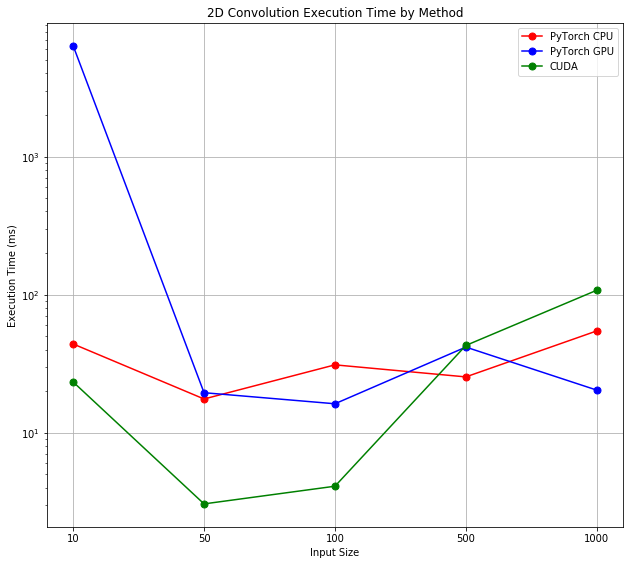

In [4]:
#####################################################################################
#  TODO: conv2d() time profile and plot.                                            #
#        You will need to define a conv mask. You may define any mask shape.        #
#                                                                                   #
# --------------------------- YOUR IMPLEMENTATION HERE ---------------------------- #
#####################################################################################
time_pytorch_cpu = []
time_pytorch_gpu = []
time_cuda = []

mask = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

for input_size in INPUT_SIZES:
    
    time_pytorch_cpu_total = 0
    time_pytorch_gpu_total = 0
    time_cuda_total = 0
    
    for _ in range(iterations):
        input_array = np.random.randint(-10, high=10, size=(input_size, input_size)).astype(np.float32)
        input_array_pytorch_cpu = torch.from_numpy(input_array).unsqueeze(0).unsqueeze(0)
        mask_pytorch_cpu = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)

        pytorch_cpu_start = time.time()
        output_array_pytorch_cpu = F.conv2d(input_array_pytorch_cpu, mask_pytorch_cpu, padding='same')
        pytorch_cpu_end = time.time()
        time_pytorch_cpu_total += (pytorch_cpu_end - pytorch_cpu_start) * 1000

        pytorch_gpu_start = time.time()
        input_array_pytorch_gpu = input_array_pytorch_cpu.to(device)
        mask_pytorch_gpu = mask_pytorch_cpu.to(device)
        output_array_pytorch_gpu = F.conv2d(input_array_pytorch_gpu, mask_pytorch_gpu, padding='same')
        output_array_pytorch_gpu = output_array_pytorch_gpu.cpu()
        torch.cuda.synchronize()
        pytorch_gpu_end = time.time()
        time_pytorch_gpu_total += (pytorch_gpu_end - pytorch_gpu_start) * 1000

        cuda_start = time.time()
        cuda_output = cuda_functions.conv2d(input_array, mask)
        torch.cuda.synchronize()
        cuda_end = time.time()
        time_cuda_total += (cuda_end - cuda_start) * 1000

    time_pytorch_cpu.append(time_pytorch_cpu_total / iterations)
    time_pytorch_gpu.append(time_pytorch_gpu_total / iterations)
    time_cuda.append(time_cuda_total / iterations)

title = "2D Convolution Execution Time by Method"
plot_execution_times(time_pytorch_cpu, time_pytorch_gpu, time_cuda, title)


#####################################################################################
# --------------------------- END YOUR IMPLEMENTATION ----------------------------- #
#  END TODO                                                                         #
#####################################################################################

### Discuss the results of the conv2d() time profile.

<font color="red"><strong>TODO:</strong></font>At small input sizes, both PyTorch's CPU implementation and our CUDA implementation are relatively fast, while PyTorch's GPU implementation is significantly slower. This is mainly because GPUs have larger fixed overheads (such as data transfer and kernel startup), and when the computational load is small, these overheads dominate. 
For medium-sized inputs (such as 50 and 100), our CUDA implementation performs the best. This indicates that at this point, the computational load is large enough to take advantage of the GPU's parallel capabilities, and the overhead has not become excessively high, thus achieving the peak performance. 
When the input size is large (such as 500 and 1000), PyTorch GPU begins to perform better and gradually surpasses our CUDA implementation. This is because PyTorch utilizes highly optimized GPU libraries and more efficient memory management mechanisms, enabling better scalability in large-scale computations. In contrast, our CUDA implementation is relatively simpler.

### MaxPool2d Timing

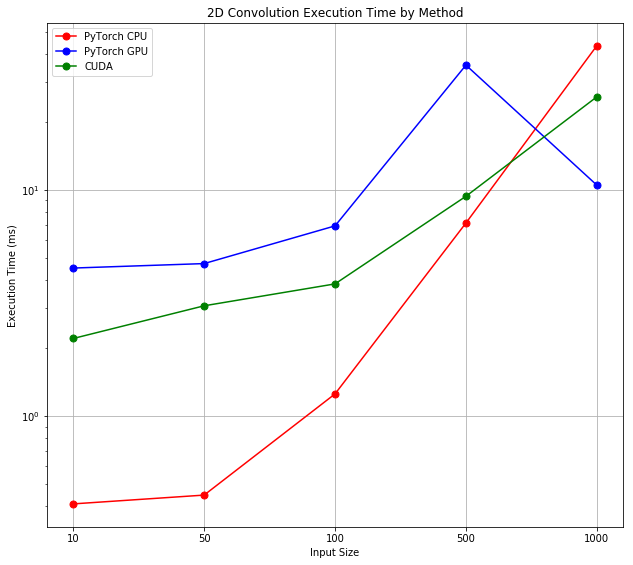

In [5]:
#####################################################################################
#  TODO: MaxPool2d() time profile and plot. You may use any pooling kernel size.    #
#                                                                                   #
# --------------------------- YOUR IMPLEMENTATION HERE ---------------------------- #
#####################################################################################
time_pytorch_cpu = []
time_pytorch_gpu = []
time_cuda = []

mask = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

for input_size in INPUT_SIZES:
    
    time_pytorch_cpu_total = 0
    time_pytorch_gpu_total = 0
    time_cuda_total = 0
    
    for _ in range(iterations):
        input_array = np.random.randint(-10, high=10, size=(input_size, input_size)).astype(np.float32)
        
        input_array_pytorch_cpu = torch.from_numpy(input_array).unsqueeze(0).unsqueeze(0)
        mask_pytorch_cpu = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)

        pytorch_cpu_start = time.time()
        output_array_pytorch_cpu = F.conv2d(input_array_pytorch_cpu, mask_pytorch_cpu, padding='same')
        pytorch_cpu_end = time.time()
        time_pytorch_cpu_total += (pytorch_cpu_end - pytorch_cpu_start) * 1000

        pytorch_gpu_start = time.time()
        input_array_pytorch_gpu = input_array_pytorch_cpu.to(device)
        mask_pytorch_gpu = mask_pytorch_cpu.to(device)
        output_array_pytorch_gpu = F.conv2d(input_array_pytorch_gpu, mask_pytorch_gpu, padding='same')
        output_array_pytorch_gpu = output_array_pytorch_gpu.cpu()
        torch.cuda.synchronize()
        pytorch_gpu_end = time.time()
        time_pytorch_gpu_total += (pytorch_gpu_end - pytorch_gpu_start) * 1000

        cuda_start = time.time()
        cuda_output = cuda_functions.conv2d(input_array, mask)
        torch.cuda.synchronize()
        cuda_end = time.time()
        time_cuda_total += (cuda_end - cuda_start) * 1000

    time_pytorch_cpu.append(time_pytorch_cpu_total / iterations)
    time_pytorch_gpu.append(time_pytorch_gpu_total / iterations)
    time_cuda.append(time_cuda_total / iterations)

title = "2D Convolution Execution Time by Method"
plot_execution_times(time_pytorch_cpu, time_pytorch_gpu, time_cuda, title)


#####################################################################################
# --------------------------- END YOUR IMPLEMENTATION ----------------------------- #
#  END TODO                                                                         #
#####################################################################################

### Discuss the results of the MaxPool2d() time profile.

<font color="red"><strong>TODO:</strong></font> Your discussion here

### linear Timing

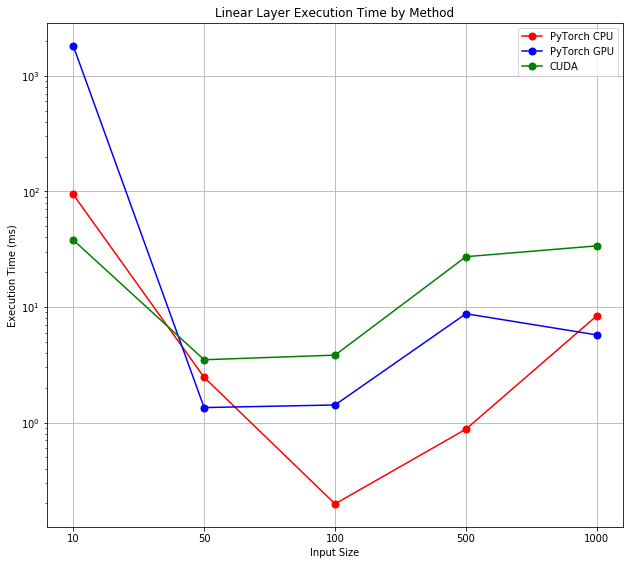

In [6]:
#####################################################################################
# TODO: linear() time profile and plot. Define weight and bias shapes corresponding #
#       to the input size.                                                          #
#                                                                                   #
# --------------------------- YOUR IMPLEMENTATION HERE ---------------------------- #
#####################################################################################
time_pytorch_cpu = []
time_pytorch_gpu = []
time_cuda = []

for input_size in INPUT_SIZES:
    
    time_pytorch_cpu_total = 0
    time_pytorch_gpu_total = 0
    time_cuda_total = 0
    
    for _ in range(iterations):
        input_array = np.random.randint(-10, high=10, size=(input_size,)).astype(np.float32)
        weights = np.random.randint(-10, high=10, size=(input_size, input_size)).astype(np.float32)
        bias = np.random.randint(-10, high=10, size=(input_size,)).astype(np.float32)

        input_array_pytorch_cpu = torch.from_numpy(input_array).unsqueeze(0).unsqueeze(0)
        weights_pytorch_cpu = torch.from_numpy(weights)
        bias_pytorch_cpu = torch.from_numpy(bias)

        pytorch_cpu_start = time.time()
        output_array_pytorch_cpu = F.linear(input_array_pytorch_cpu, weights_pytorch_cpu, bias=bias_pytorch_cpu)
        pytorch_cpu_end = time.time()
        time_pytorch_cpu_total += (pytorch_cpu_end - pytorch_cpu_start) * 1000

        pytorch_gpu_start = time.time()
        input_array_pytorch_gpu = input_array_pytorch_cpu.to(device)
        weights_pytorch_gpu = weights_pytorch_cpu.to(device)
        bias_pytorch_gpu = bias_pytorch_cpu.to(device)
        output_array_pytorch_gpu = F.linear(input_array_pytorch_gpu, weights_pytorch_gpu, bias=bias_pytorch_gpu)
        output_array_pytorch_gpu = output_array_pytorch_gpu.cpu()
        torch.cuda.synchronize()
        pytorch_gpu_end = time.time()
        time_pytorch_gpu_total += (pytorch_gpu_end - pytorch_gpu_start) * 1000

        cuda_start = time.time()
        cuda_output = cuda_functions.linear(input_array, weights, bias)
        torch.cuda.synchronize()
        cuda_end = time.time()
        time_cuda_total += (cuda_end - cuda_start) * 1000

    time_pytorch_cpu.append(time_pytorch_cpu_total / iterations)
    time_pytorch_gpu.append(time_pytorch_gpu_total / iterations)
    time_cuda.append(time_cuda_total / iterations)

title = "Linear Layer Execution Time by Method"
plot_execution_times(time_pytorch_cpu, time_pytorch_gpu, time_cuda, title)


#####################################################################################
# --------------------------- END YOUR IMPLEMENTATION ----------------------------- #
# END TODO                                                                          #
#####################################################################################

### Discuss the results of the linear() time profile.

<font color="red"><strong>TODO:</strong></font> Your discussion here